In [3]:
# --- Imports & path setup -------------------------------------------------
import sys, json
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import pandas as pd
from IPython.display import Image, display, Markdown

from data_loader import PROJECT_ROOT
from analyze_study import analyze

DATASET = "fashion_mnist"
FRAMEWORK = "pymoo"
OTHER_FRAMEWORK = "botorch"

In [4]:
STUDY_DIR = Path(r"D:/forKrishna/MOML/full_moo/pymoo/pymoo_nsga2_fashion_mnist_20260428_061103")

if not STUDY_DIR.exists():
    raise SystemExit(f"H200 study dir not found at {STUDY_DIR}."
                     f"Run: python -c \"from huggingface_hub import snapshot_download; snapshot_download(repo_id='jester1177/moml-results', repo_type='dataset', local_dir='D:/forKrishna/MOML/full_moo')\"")

print(f"Study dir: {STUDY_DIR}")
print(f"Files    : {sorted(p.name for p in STUDY_DIR.iterdir())}")

Study dir: D:\forKrishna\MOML\full_moo\pymoo\pymoo_nsga2_fashion_mnist_20260428_061103
Files    : ['appendix_solution.json', 'pareto_front.csv', 'pareto_metrics.json', 'pareto_table.csv', 'plot_2d_panels.png', 'plot_3d_pareto.png', 'plot_3d_scatter.png', 'summary.json', 'trials.csv']


In [5]:
with (STUDY_DIR / "summary.json").open() as f:
    summary = json.load(f)

print(f"Framework      : {summary.get('framework')} — {summary.get('algorithm')}")
print(f"Dataset        : {summary.get('dataset_name')}")
print(f"Device         : {summary.get('device')}")
print(f"Trials         : {summary.get('n_trials_completed')}  (pop={summary.get('pop_size')} × gen={summary.get('n_gen')})")
print(f"Train subset   : {summary.get('train_subset_size')}")
print(f"Seed           : {summary.get('seed')}")
if summary.get('use_amp') is not None:
    print(f"AMP            : {summary.get('use_amp')}")
print(f"Elapsed        : {summary.get('elapsed_seconds', 0)/60:.1f} min")
print(f"Pareto pts     : {summary.get('n_pareto_points')}  (final population non-dominated set)")

Framework      : pymoo — NSGA2
Dataset        : fashion_mnist
Device         : cuda
Trials         : 200  (pop=40 × gen=5)
Train subset   : None
Seed           : 42
AMP            : True
Elapsed        : 47.9 min
Pareto pts     : 40  (final population non-dominated set)


In [6]:
# Recompute analysis (rebuilds metrics + plots fresh from trials.csv).
metrics = analyze(STUDY_DIR)

print(f"n_trials       : {metrics['n_trials']}")
print(f"n_pareto       : {metrics['n_pareto_points']}  (recomputed over ALL trials, not just final pop)")
print(f"hypervolume    : {metrics['hypervolume']:,.2f}   (higher = better)")
print(f"spacing        : {metrics['spacing']:.4f}   (lower = better, more uniform)")
print()
print("Best objective values seen:")
print(f"  best accuracy     : {metrics['extremes']['accuracy_max']:.4f}")
print(f"  fastest inference : {metrics['extremes']['inference_ms_min']:.4f} ms")
print(f"  smallest model    : {metrics['extremes']['param_count_min']:,} params")

n_trials       : 200
n_pareto       : 48  (recomputed over ALL trials, not just final pop)
hypervolume    : 9,212,041,817.46   (higher = better)
spacing        : 0.0625   (lower = better, more uniform)

Best objective values seen:
  best accuracy     : 0.9218
  fastest inference : 0.1224 ms
  smallest model    : 1,322 params


In [7]:
table = pd.read_csv(STUDY_DIR / "pareto_table.csv")
table.set_index("label", inplace=True)
table

,trial_number,accuracy,inference_ms,param_count,arch_type,num_conv_layers,num_channels,num_fc_units,learning_rate,batch_size,num_epochs,dropout_rate,optimizer_type,input_resolution
label,,,,,,,,,,,,,,
fast,138,0.7099,0.1224,2538,plain,1,8,128,0.001621,128,7,0.011578,Adam,16
small,156,0.7135,0.1567,1322,plain,1,8,64,0.001815,256,9,0.140617,Adam,16
accurate,157,0.9218,2.6848,276554,plain,4,32,256,0.005999,64,9,0.373483,SGD,28
balanced,64,0.8654,0.2280,15914,plain,2,16,256,0.005613,64,8,0.476450,Adam,16


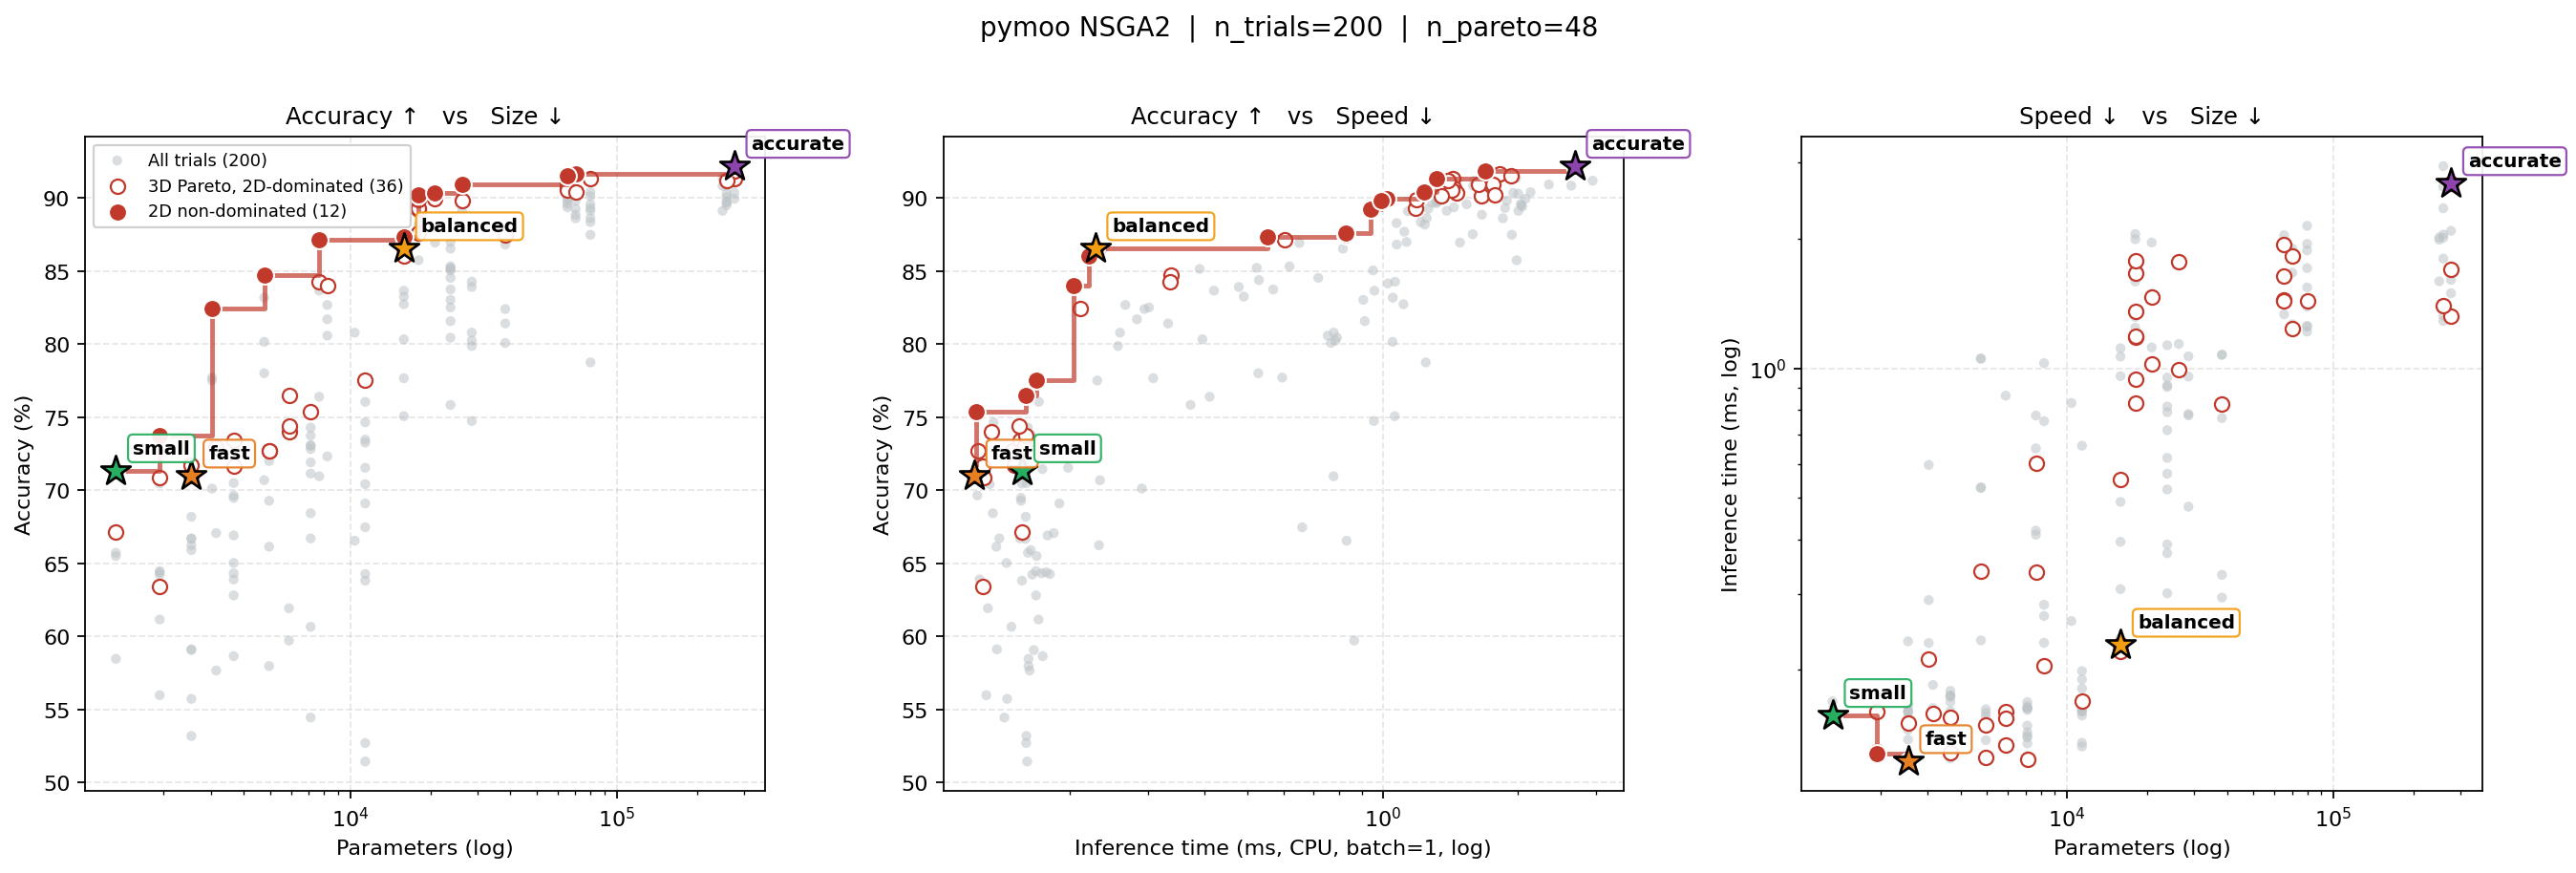

In [8]:
display(Image(filename=str(STUDY_DIR / "plot_2d_panels.png")))

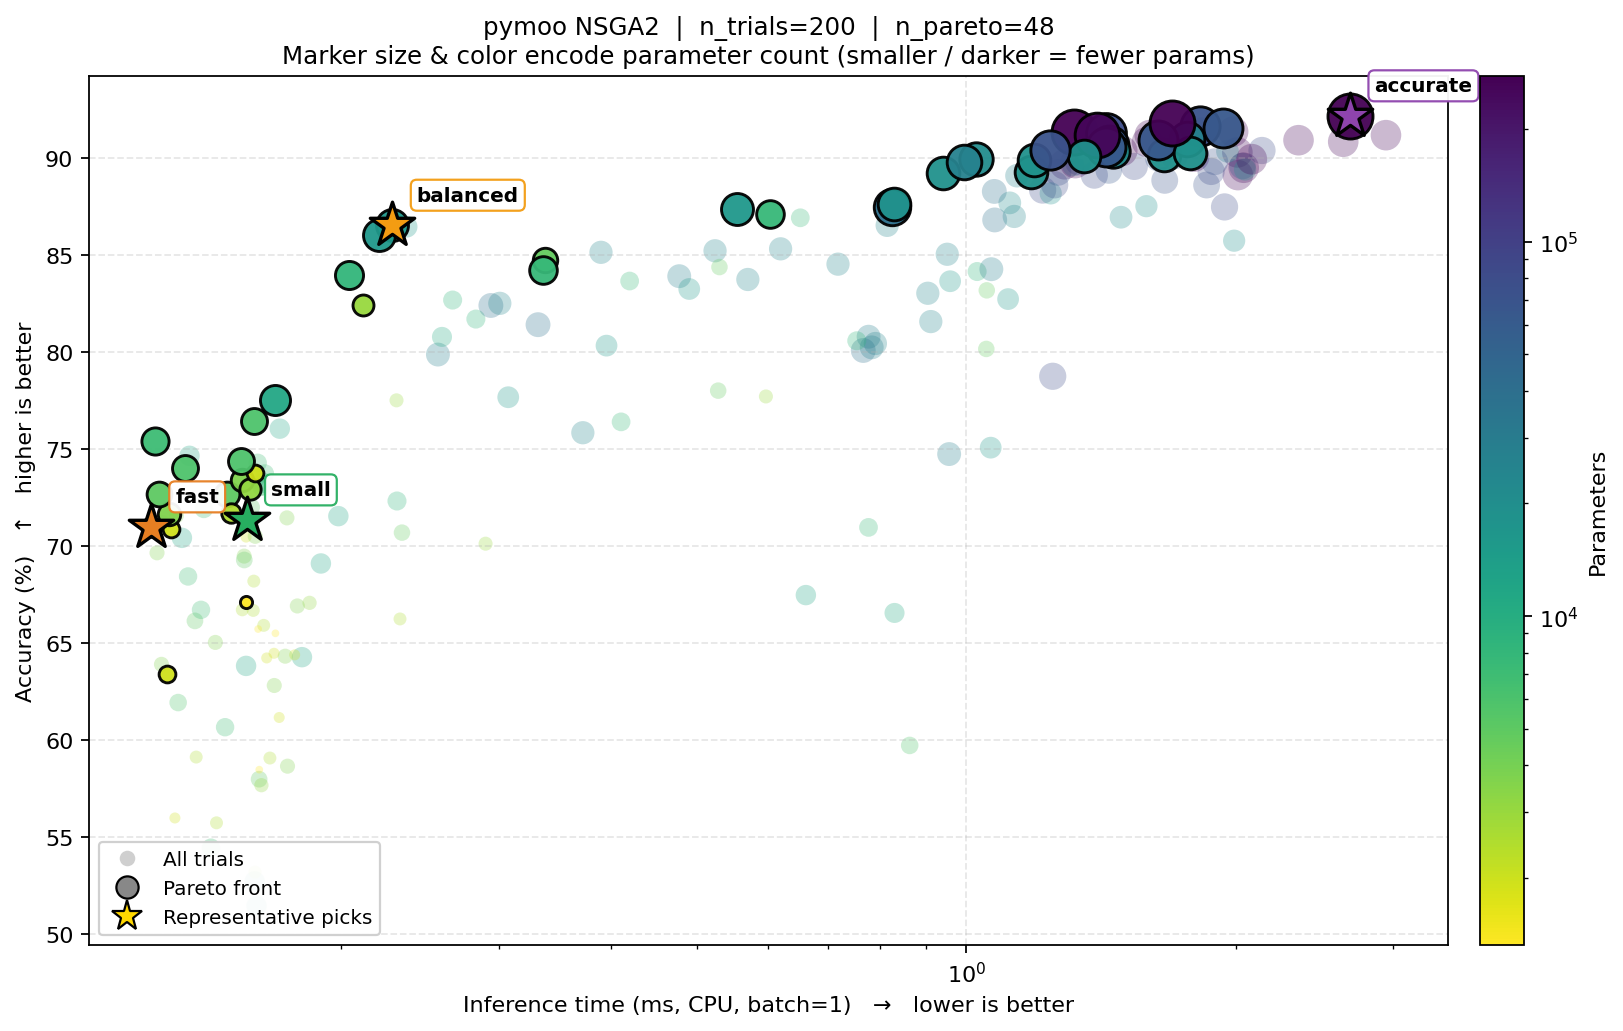

In [9]:
display(Image(filename=str(STUDY_DIR / "plot_3d_scatter.png")))

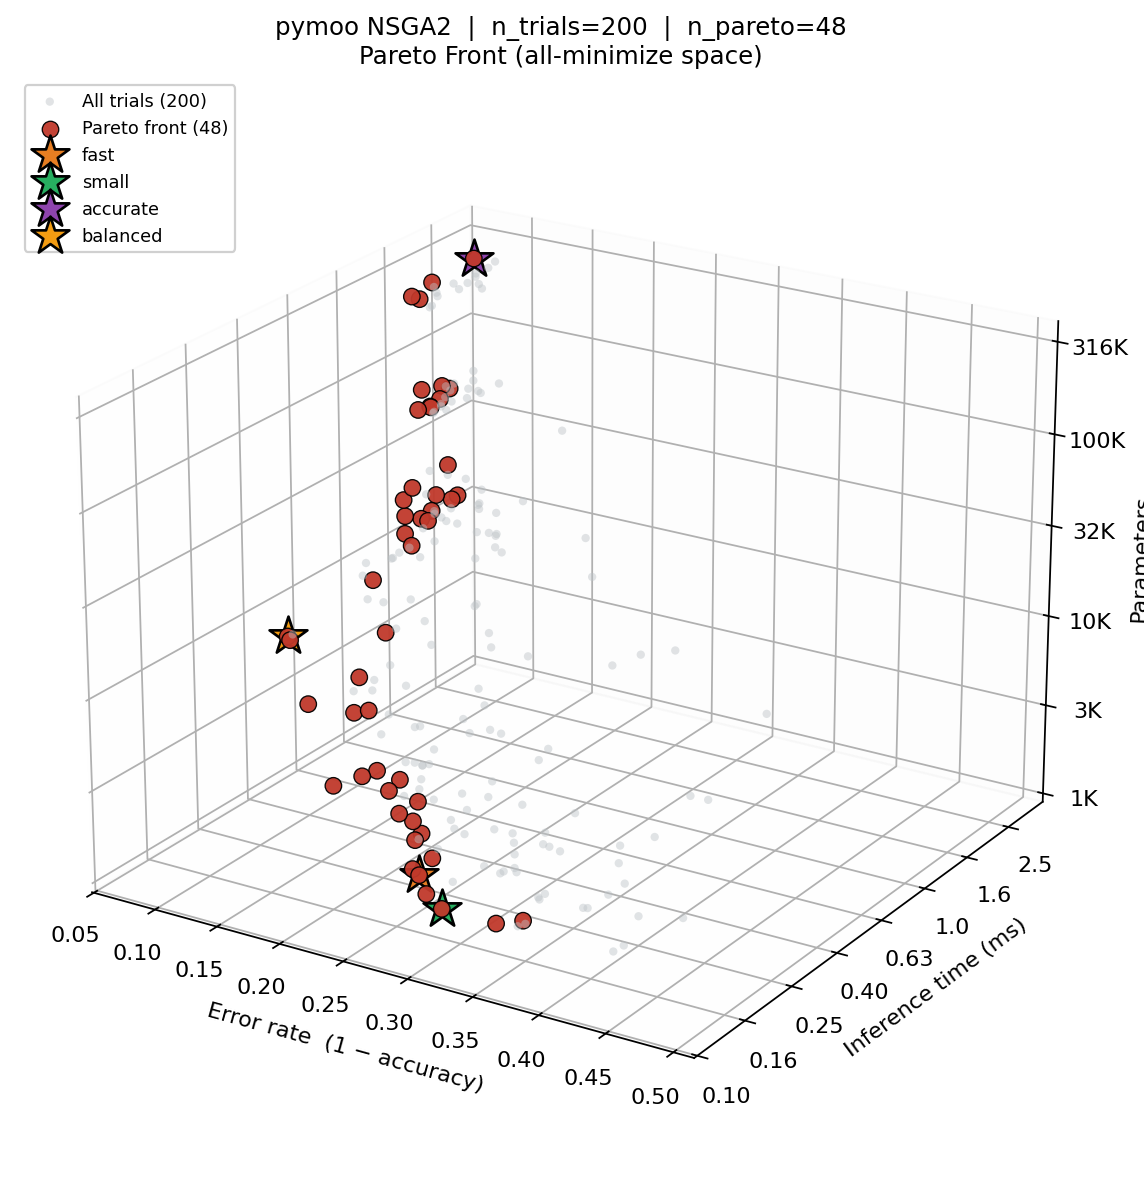

In [10]:
display(Image(filename=str(STUDY_DIR / "plot_3d_pareto.png")))

In [11]:
with (STUDY_DIR / "appendix_solution.json").open() as f:
    appendix = json.load(f)

print(f"Label        : {appendix['label']}")
print(f"Trial number : {appendix.get('trial_number')}")
print()
print("--- Objectives ---")
for k, v in appendix['objectives'].items():
    print(f"  {k:<14s} : {v}")
print()
print("--- Decision variables ---")
for k, v in appendix['decision_variables'].items():
    print(f"  {k:<18s} : {v}")

Label        : balanced (closest-to-ideal Pareto point)
Trial number : 64

--- Objectives ---
  accuracy       : 0.8654
  inference_ms   : 0.228021
  param_count    : 15914

--- Decision variables ---
  arch_type          : plain
  num_conv_layers    : 2
  num_channels       : 16
  num_fc_units       : 256
  learning_rate      : 0.0056129509859034945
  batch_size         : 64
  num_epochs         : 8
  dropout_rate       : 0.4764496975348725
  optimizer_type     : Adam
  input_resolution   : 16


In [12]:
# Compare against the H200 BoTorch run (also pulled from HF).
candidate = Path("D:/forKrishna/MOML/full_moo/botorch/fashion_mnist") if Path("D:/forKrishna/MOML/full_moo/botorch/fashion_mnist").exists() else Path("D:/forKrishna/MOML/full_moo/botorch")
compare_path = None
if candidate.exists():
    other_runs = sorted([p for p in candidate.iterdir() if p.is_dir()], key=lambda p: p.name)
    if other_runs:
        compare_path = other_runs[-1] / "pareto_front.csv"

if compare_path is None or not compare_path.exists():
    print(f"No BoTorch H200 run found under {candidate}.")
    print(f"Once the H200 BoTorch run finishes and uploads, re-pull the HF dataset and re-run this cell.")
else:
    print(f"Comparing against : {compare_path.parent.name}")
    print()
    metrics_cmp = analyze(STUDY_DIR, compare_pareto_path=compare_path)
    if "comparison" in metrics_cmp:
        c = metrics_cmp["comparison"]
        print("--- joint-front analysis ---")
        print(f"joint pareto      : {c['joint_n_pareto']}")
        print(f"ours surviving    : {c['ours_surviving_in_joint']:>3d} / {metrics_cmp['n_pareto_points']}  ({100*c['ours_surviving_in_joint']/max(1,metrics_cmp['n_pareto_points']):.0f}%)")
        print(f"other surviving   : {c['other_surviving_in_joint']:>3d} / {c['compare_n_pareto']}  ({100*c['other_surviving_in_joint']/max(1,c['compare_n_pareto']):.0f}%)")
        print(f"GD ours -> joint  : {c['gd_ours_to_joint']:.6f}  (lower = better)")
        print(f"GD other-> joint  : {c['gd_other_to_joint']:.6f}")
        print()
        winner = "pymoo" if c['gd_ours_to_joint'] < c['gd_other_to_joint'] else "botorch"
        print(f"Closer to joint front (lower GD): {winner}")
    print()
    print("Plots have been refreshed with the comparison overlay. Re-display them with the cells above.")

No BoTorch H200 run found under D:\forKrishna\MOML\full_moo\botorch.
Once the H200 BoTorch run finishes and uploads, re-pull the HF dataset and re-run this cell.


**2D panels with both fronts (red = ours, blue diamonds = comparison)**

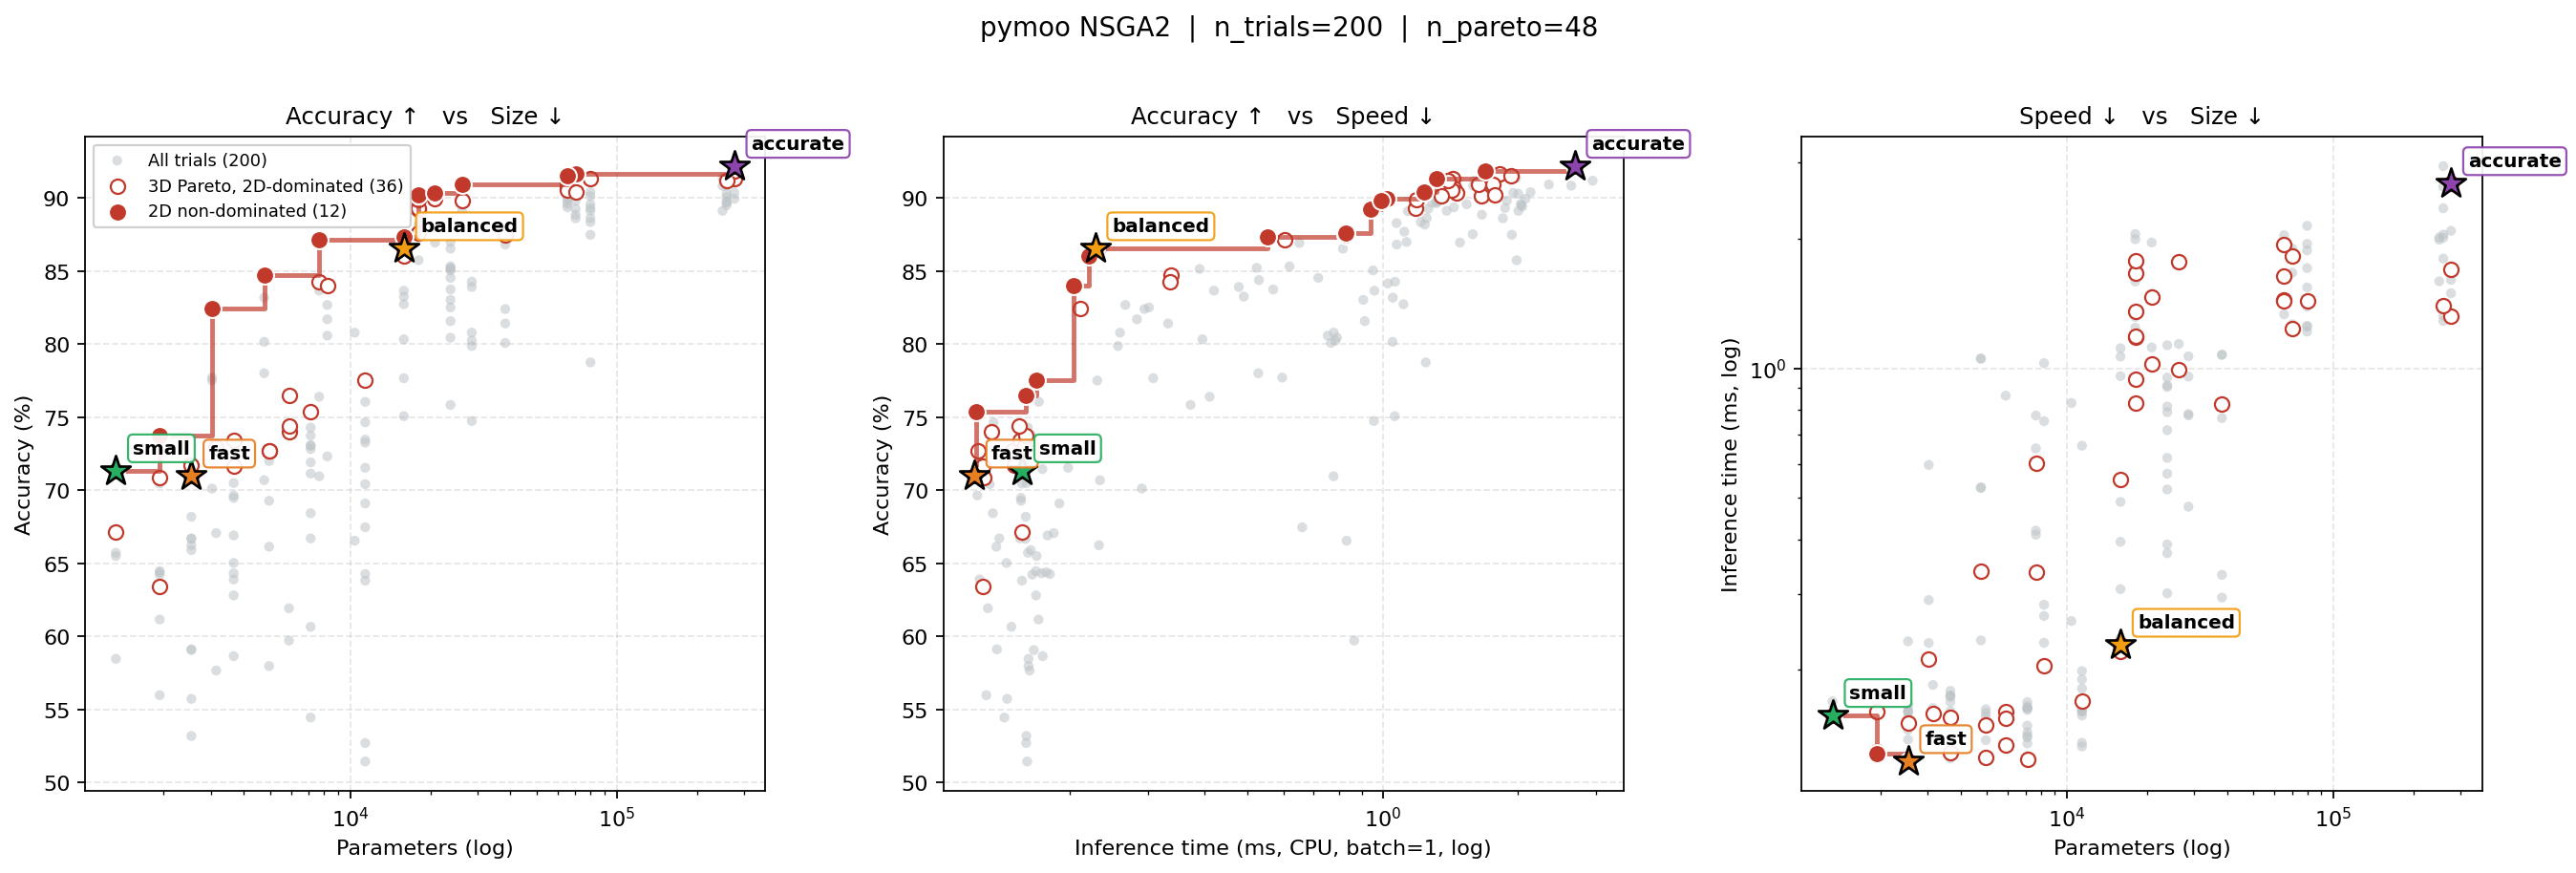

**2D bubble with comparison Pareto (magenta-edged diamonds)**

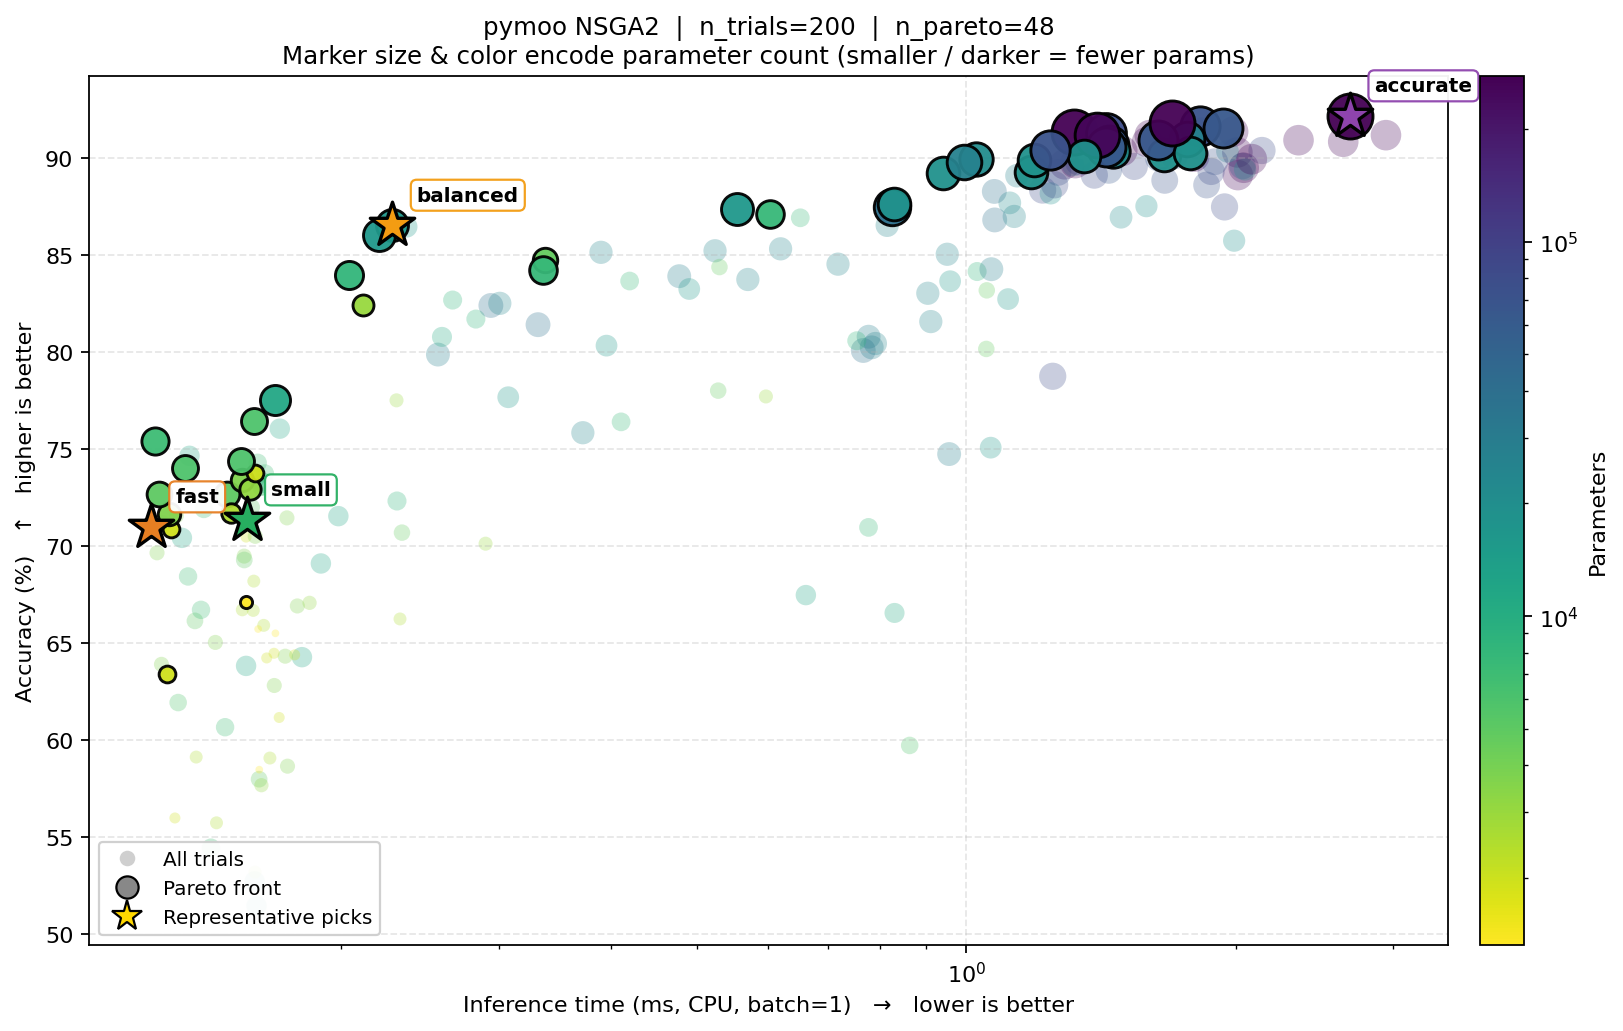

**3D Pareto with comparison overlay (blue diamonds)**

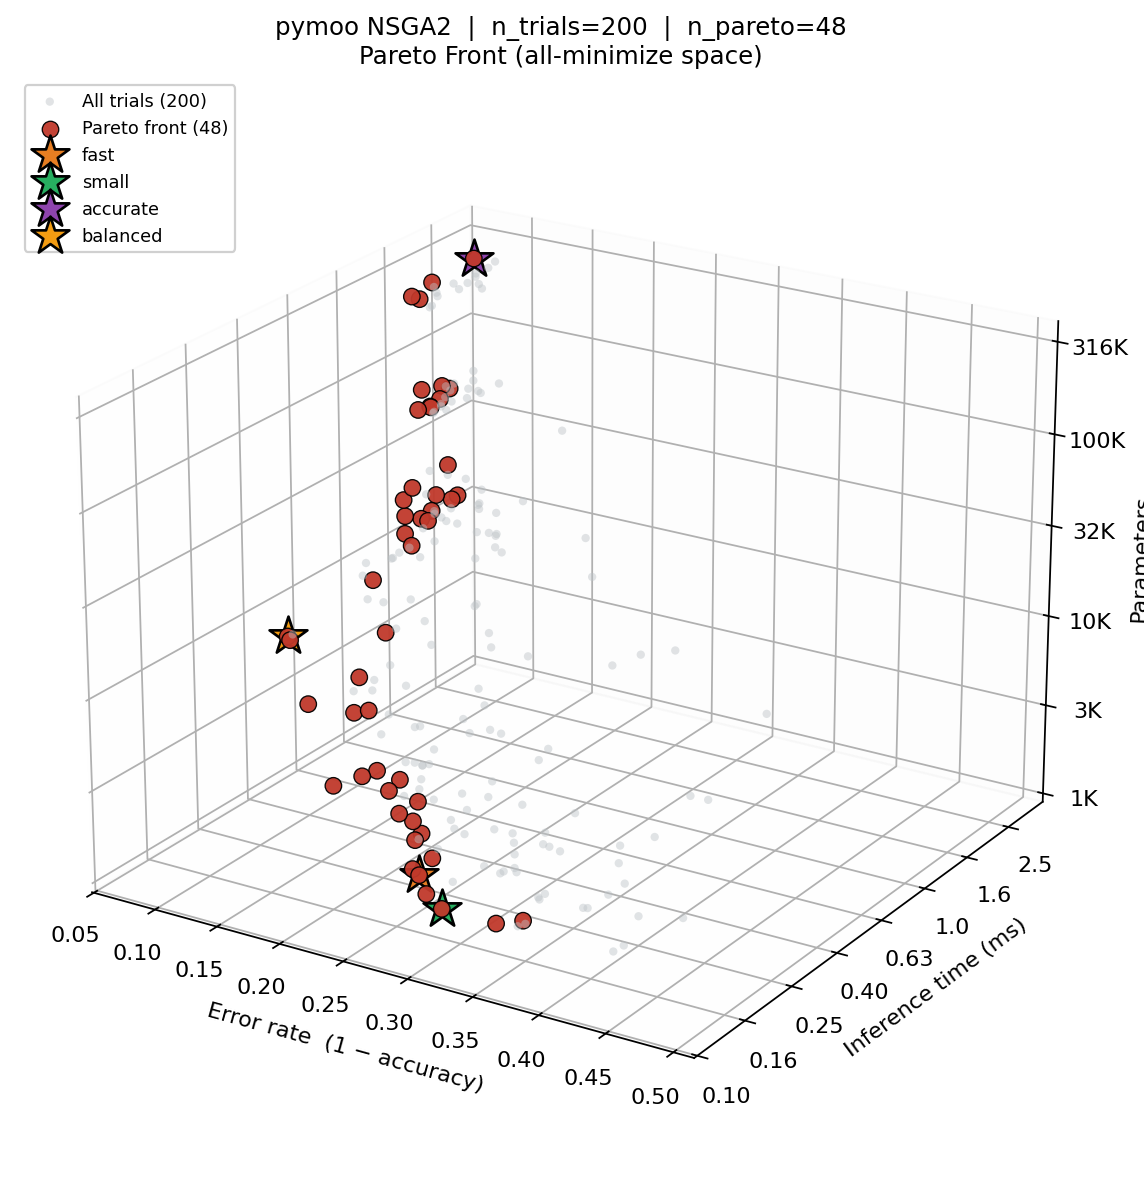

In [13]:
for fname, caption in [
    ("plot_2d_panels.png",       "2D panels with both fronts (red = ours, blue diamonds = comparison)"),
    ("plot_3d_scatter.png",      "2D bubble with comparison Pareto (magenta-edged diamonds)"),
    ("plot_3d_pareto.png",       "3D Pareto with comparison overlay (blue diamonds)"),
]:
    display(Markdown(f"**{caption}**"))
    display(Image(filename=str(STUDY_DIR / fname)))